In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import  OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import f_regression


In [4]:
df=pd.read_csv('diabetes.csv')

In [5]:
df.shape

(768, 9)

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### As per the information collected from the given dataset all the columns in the data set are of numerical type

In [8]:
### Satistical informaion of the dataset
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


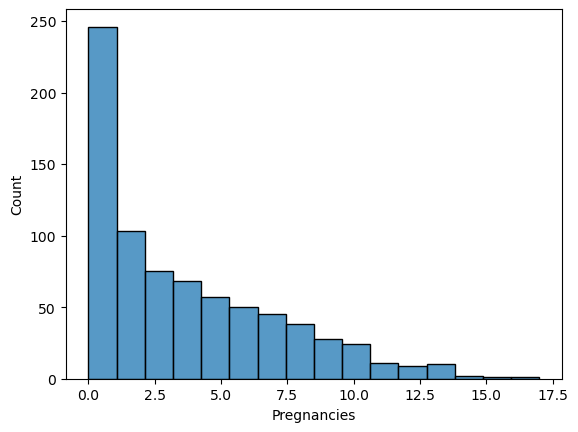

In [9]:
### creating Histograms of the features
sns.histplot(data=df,x='Pregnancies')
plt.show()

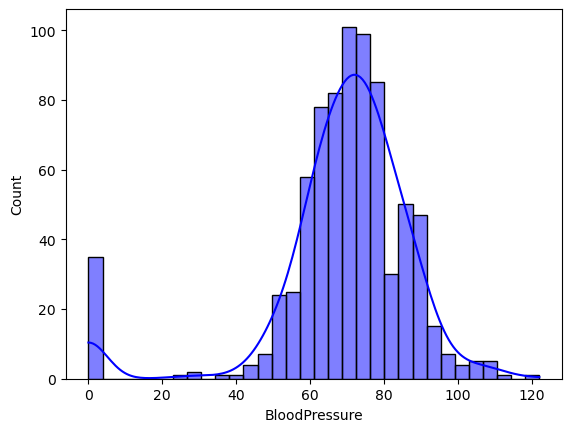

In [10]:
sns.histplot(data=df,x='BloodPressure',kde=True,color='blue')
plt.show()

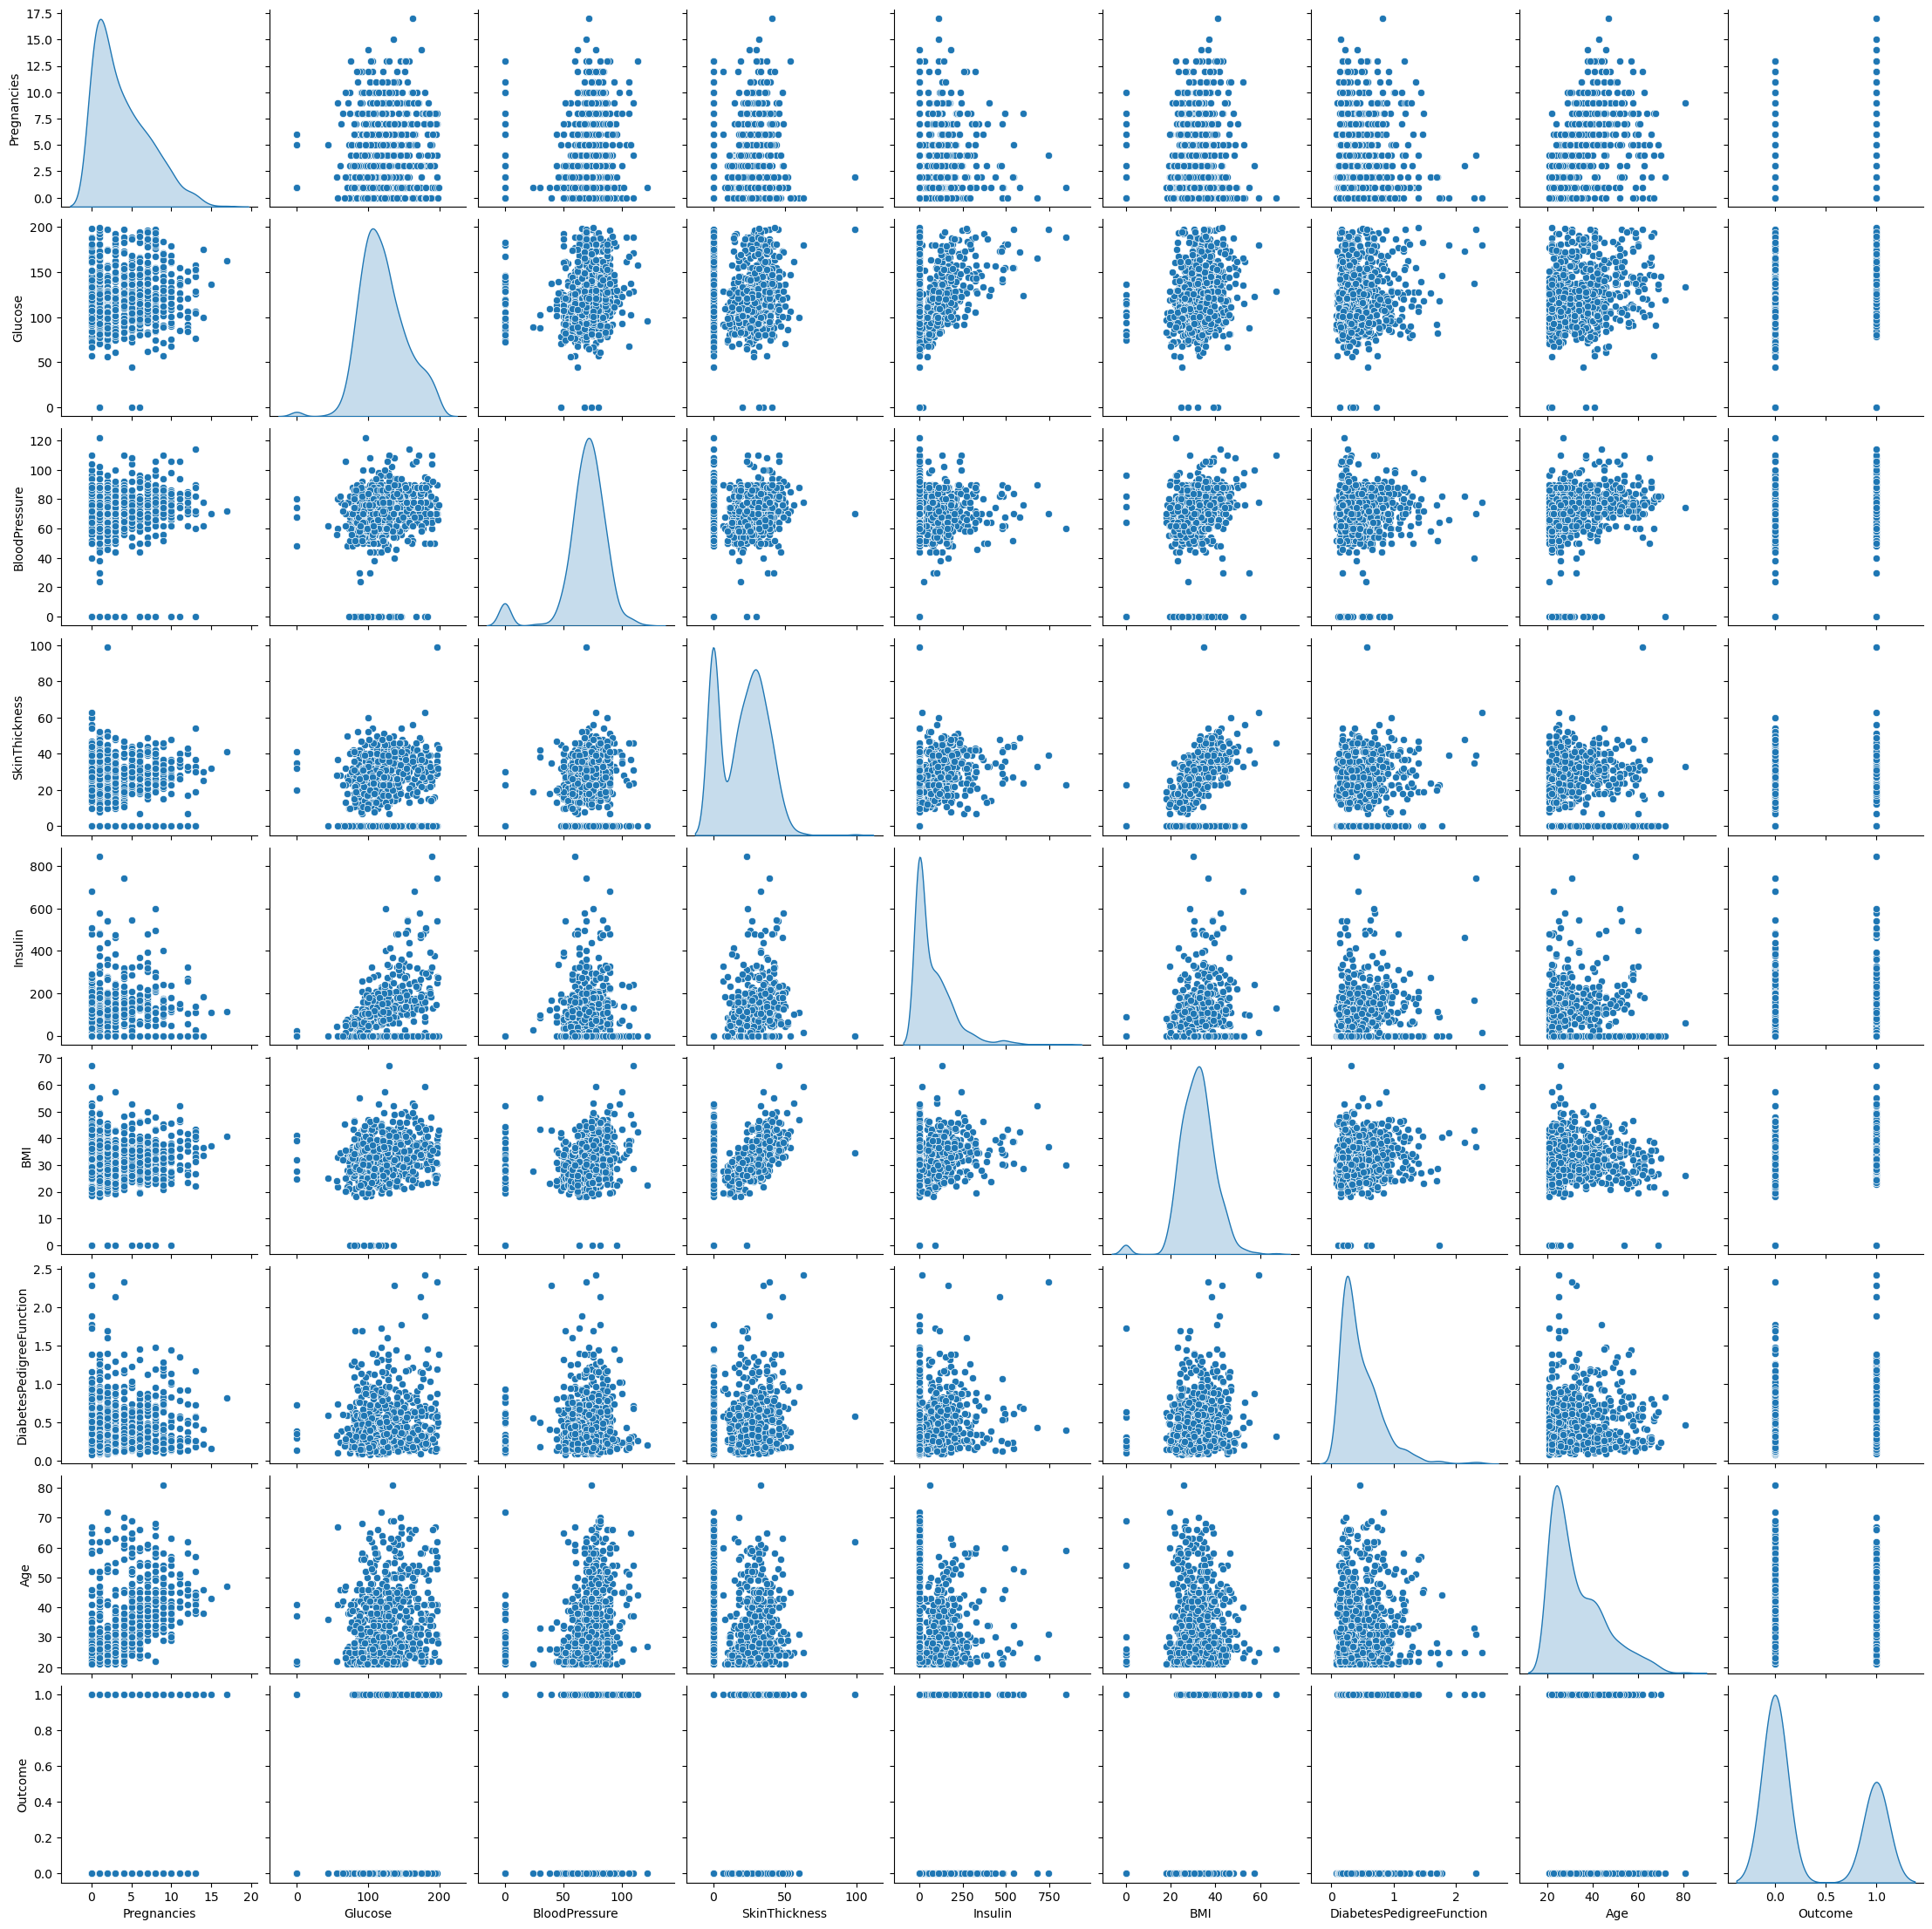

In [11]:
### Getting pair plot for all the data given
sns.pairplot(data=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age','Outcome']],diag_kind='kde')
plt.show()

In [12]:
### the above pairplot  is combination of Histograms along with density plot
## implies that all the columns in the dataset are of continuous type and the Outcome column is discrete type
## to check whether the data is normally distribut, we need to find the skewners value of particular column
df['Pregnancies'].skew(),df['BloodPressure'].skew(),df['Glucose'].skew(),df['SkinThickness'].skew(), df['Insulin'].skew(),df['BMI'].skew(),df['DiabetesPedigreeFunction'].skew(),df['Age'].skew()


(np.float64(0.9016739791518588),
 np.float64(-1.8436079833551302),
 np.float64(0.17375350179188992),
 np.float64(0.10937249648187608),
 np.float64(2.272250858431574),
 np.float64(-0.42898158845356543),
 np.float64(1.919911066307204),
 np.float64(1.1295967011444805))

#### as no value of the skewners is equal to 0, it is not normally distributed data

In [13]:
### Finding Correlation and visually represnet through heatmap
df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age','Outcome']].cov()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,11.354056,13.947131,9.214538,-4.390041,-28.555231,0.469774,-0.037426,21.570620,0.356618
Glucose,13.947131,1022.248314,94.430956,29.239183,1220.935799,55.726987,1.454875,99.082805,7.115079
BloodPressure,9.214538,94.430956,374.647271,64.029396,198.378412,43.004695,0.264638,54.523453,0.600697
SkinThickness,-4.390041,29.239183,64.029396,254.473245,802.979941,49.373869,0.972136,-21.381023,0.568747
Insulin,-28.555231,1220.935799,198.378412,802.979941,13281.180078,179.775172,7.066681,-57.143290,7.175671
BMI,0.469774,55.726987,43.004695,49.373869,179.775172,62.159984,0.367405,3.360330,1.100638
DiabetesPedigreeFunction,-0.037426,1.454875,0.264638,0.972136,7.066681,0.367405,0.109779,0.130772,0.027472
Age,21.570620,99.082805,54.523453,-21.381023,-57.143290,3.360330,0.130772,138.303046,1.336953
Outcome,0.356618,7.115079,0.600697,0.568747,7.175671,1.100638,0.027472,1.336953,0.227483


In [14]:
### finding correlation() which means bringing the values of covariance in the range of -1 to +1
corr=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age','Outcome']].corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

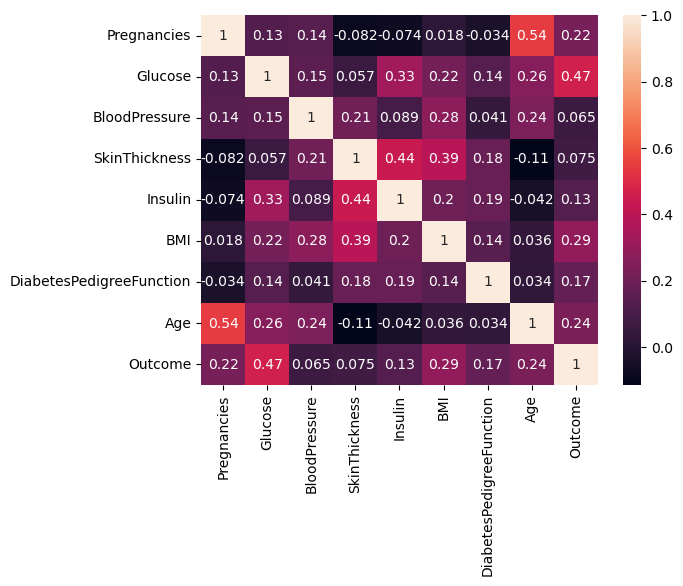

In [15]:
sns.heatmap(data=corr,annot=True)

In [16]:
### performing EDA
## checking for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

##### No missing values are present in the dataset
#####  checking for duplicates

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
## selecting target and features
target=df[['Outcome']]
features=df.drop(columns=['Outcome'])

In [19]:
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [20]:
## no duplicates are present in the dataset
### checking for outliers

<Axes: >

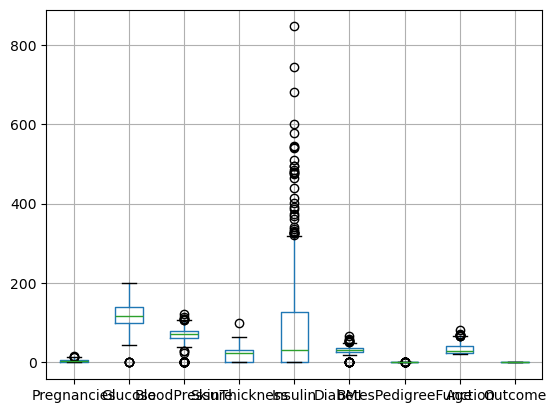

In [21]:
df.boxplot()

In [22]:
### Outliers are present in the data
### Removing the outliers by capping

In [23]:
def outlier_cappping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in features.select_dtypes(['int','float']).columns:
    outlier_cappping(features,col)

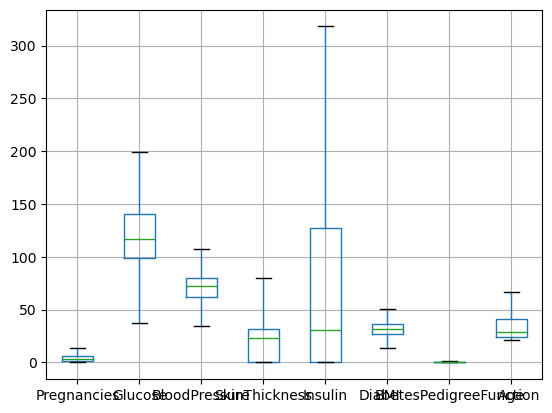

In [24]:
features.boxplot()
plt.show()

### No outliers are present

In [25]:
### Feature Selection
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(614, 8)
(154, 8)
(614, 1)
(154, 1)


In [26]:
### As no categorical data is present in data set , no need of labelling the data and no need of using Ordinal Encoder

In [27]:
features.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

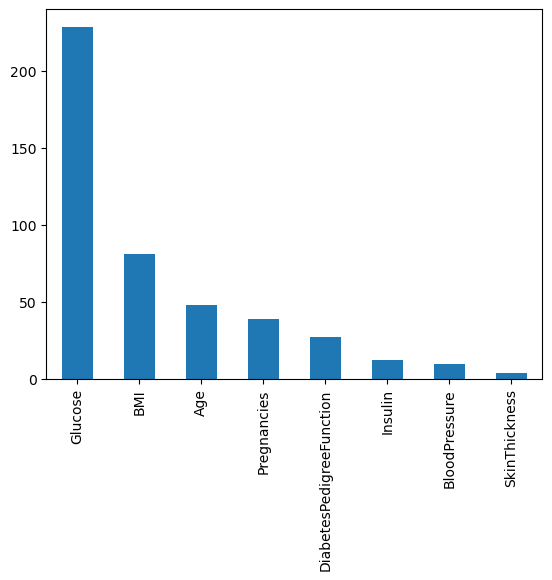

In [28]:
## Using f_regrr to check the relationship between the features and target
f_reg=f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

### As the relationship with the 'SkinThickness' and 'BloodPressure' column is very less . if needed we can drop these two columns, but dropping these columns could lead to loss of some data 

In [29]:
target= df[['Outcome']]
features=df.drop(columns=['Outcome'])
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [30]:
features_1=features.drop(columns=['BloodPressure','SkinThickness'])
features_1.head()

,Pregnancies,Glucose,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,0,33.6,0.627,50
1,1,85,0,26.6,0.351,31
2,8,183,0,23.3,0.672,32
3,1,89,94,28.1,0.167,21
4,0,137,168,43.1,2.288,33


In [31]:
### Scaling using Standard Scaler by fit and transform
std_sca=StandardScaler()
x_train[[ 'Pregnancies', 'Glucose', 'Insulin',
         'BMI', 'DiabetesPedigreeFunction', 'Age','Glucose', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']]=std_sca.fit_transform(x_train[['Pregnancies', 'Glucose', 'Insulin',
         'BMI', 'DiabetesPedigreeFunction', 'Age','Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']])
x_test[['Pregnancies', 'Glucose', 'Insulin',
         'BMI', 'DiabetesPedigreeFunction', 'Age','Glucose', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']]=std_sca.fit_transform(x_test[['Pregnancies', 'Glucose', 'Insulin',
         'BMI', 'DiabetesPedigreeFunction', 'Age','Glucose', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']])

In [32]:
log_model=LogisticRegression()
log_model.fit(x_train,y_train)

LogisticRegression()

In [33]:
### finding out the coefficients of the logistic regression model
log_model.coef_

array([[ 0.34810951,  1.17537688, -0.01024471, -0.00578224, -0.08116691,
         0.73710378,  0.45197   ,  0.23106425]])

In [34]:
log_model.intercept_

array([-0.06367529])

In [35]:
y_pred=log_model.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [36]:
#### Changing the thershold

y_pred1= [1 if x[1]>=0.6 else 0 for x in log_model.predict_proba(x_test)]
print(y_pred1)
print('Accuracy_Score:',accuracy_score(y_test,y_pred1))

[0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Accuracy_Score: 0.7337662337662337


In [37]:
accuracy_score(y_test,y_pred)

0.7402597402597403

In [38]:
y_test

,Outcome
173,0
253,0
207,1
737,0
191,0
...,...
203,0
216,1
637,0
659,1


In [39]:
#### sigmoid values based on which predict 0,1,0,1 is given
log_model.predict_proba(x_test)

array([[0.80137742, 0.19862258],
       [0.94154919, 0.05845081],
       [0.27378343, 0.72621657],
       [0.90783732, 0.09216268],
       [0.61627027, 0.38372973],
       [0.31377236, 0.68622764],
       [0.03899304, 0.96100696],
       [0.88274142, 0.11725858],
       [0.09015717, 0.90984283],
       [0.78565834, 0.21434166],
       [0.91514908, 0.08485092],
       [0.12771691, 0.87228309],
       [0.40921082, 0.59078918],
       [0.71012974, 0.28987026],
       [0.28357666, 0.71642334],
       [0.74207801, 0.25792199],
       [0.93313489, 0.06686511],
       [0.77176791, 0.22823209],
       [0.43119971, 0.56880029],
       [0.87721862, 0.12278138],
       [0.7768455 , 0.2231545 ],
       [0.99116459, 0.00883541],
       [0.48119168, 0.51880832],
       [0.01804931, 0.98195069],
       [0.73255282, 0.26744718],
       [0.1501434 , 0.8498566 ],
       [0.4962649 , 0.5037351 ],
       [0.72716442, 0.27283558],
       [0.56667973, 0.43332027],
       [0.45700499, 0.54299501],
       [0.

In [40]:
### to get only the 2nd column(sigmoid) of the above array
sigmoid=log_model.predict_proba(x_test)[:,1]
sigmoid

array([0.19862258, 0.05845081, 0.72621657, 0.09216268, 0.38372973,
       0.68622764, 0.96100696, 0.11725858, 0.90984283, 0.21434166,
       0.08485092, 0.87228309, 0.59078918, 0.28987026, 0.71642334,
       0.25792199, 0.06686511, 0.22823209, 0.56880029, 0.12278138,
       0.2231545 , 0.00883541, 0.51880832, 0.98195069, 0.26744718,
       0.8498566 , 0.5037351 , 0.27283558, 0.43332027, 0.54299501,
       0.04087751, 0.9621127 , 0.15705834, 0.45098225, 0.19514057,
       0.28120946, 0.92494077, 0.01992281, 0.19963477, 0.27341149,
       0.31905325, 0.81881   , 0.42397792, 0.07078692, 0.21744594,
       0.92169874, 0.07000109, 0.21150953, 0.90532412, 0.87553198,
       0.08495059, 0.0317691 , 0.29736993, 0.77819398, 0.76462915,
       0.89433854, 0.0847138 , 0.04815564, 0.80439734, 0.0796913 ,
       0.15687074, 0.14500737, 0.28460427, 0.30927393, 0.33847183,
       0.24337311, 0.14770159, 0.02041786, 0.19797966, 0.02156219,
       0.013744  , 0.66096792, 0.08373488, 0.23681851, 0.12962

In [41]:
#### logloss
from sklearn.metrics import log_loss
log_loss(y_test,sigmoid)

0.5497530431043219

### Performance Metrics

In [42]:
from sklearn.metrics import confusion_matrix,classification_report

In [43]:
conf=confusion_matrix(y_test,y_pred1)
conf

array([[91, 10],
       [31, 22]])

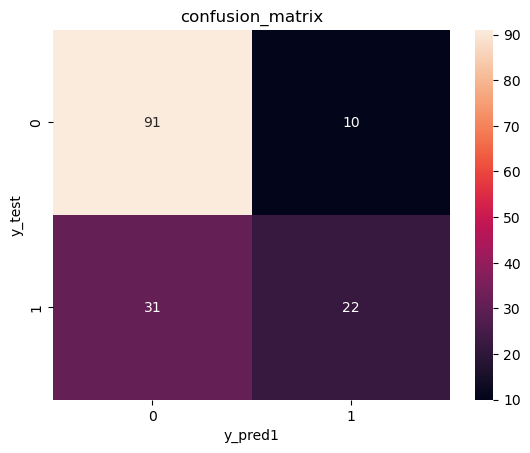

In [44]:
sns.heatmap(conf,annot=True)
plt.xlabel('y_pred1')
plt.ylabel('y_test')
plt.title('confusion_matrix')
plt.show();

In [45]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.75      0.90      0.82       101
           1       0.69      0.42      0.52        53

    accuracy                           0.73       154
   macro avg       0.72      0.66      0.67       154
weighted avg       0.73      0.73      0.71       154



#### Finding ROC Curve

In [46]:
from sklearn.metrics import roc_auc_score,roc_curve

In [47]:
auc_score=roc_auc_score(y_test,sigmoid)
auc_score

np.float64(0.7767606949374182)

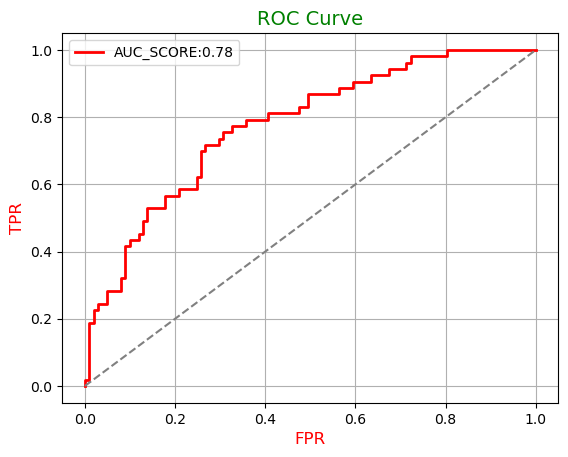

In [48]:
### to find tpr and fpr,and plot the same
fpr,tpr,thr=roc_curve(y_test,sigmoid)

plt.plot(fpr,tpr,color='red',lw=2,label=f'AUC_SCORE:{auc_score:.2f}')
plt.plot([0,1],linestyle='--',color='grey')
plt.xlabel('FPR',color='red',size=12)
plt.ylabel('TPR',color='red',size=12)
plt.title('ROC Curve',color='green',size=14)
plt.legend()
plt.grid()
plt.show()
plt.show()

#### 5. Interpretation:
a. Interpret the coefficients of the logistic regression model.

b. Discuss the significance of features in predicting the target variable (survival probability in this case).

In [51]:
# Get the feature names and their corresponding coefficients
coefficients = pd.Series(log_model.coef_[0], features.columns) 
intercept = log_model.intercept_[0]

print("Intercept:", intercept)
print("\nCoefficients:\n", coefficients)

Intercept: -0.06367529385303419

Coefficients:
 Pregnancies                 0.348110
Glucose                     1.175377
BloodPressure              -0.010245
SkinThickness              -0.005782
Insulin                    -0.081167
BMI                         0.737104
DiabetesPedigreeFunction    0.451970
Age                         0.231064
dtype: float64


In [52]:
 # Sort by absolute value for significance
coefficients_sorted = coefficients.abs().sort_values(ascending=False)
print(coefficients_sorted)

Glucose                     1.175377
BMI                         0.737104
DiabetesPedigreeFunction    0.451970
Pregnancies                 0.348110
Age                         0.231064
Insulin                     0.081167
BloodPressure               0.010245
SkinThickness               0.005782
dtype: float64


#### 6. Deployment with Streamlit:
In this task, we have to deploy our logistic regression model using Streamlit. 
The deployment can be done locally or online via Streamlit Share. 
Task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions.

(optional)For online deployment, use Streamlit Community Cloud, which supports deployment from GitHub repositories.


#### Interview Questions:
###### 1. What is the difference between precision and recall?
###### Precision
Defn: The proportion of correctly predicted positive observations to the total predicted positives.
Formula: Precision = True Positives(TP) /True Positives (TP)+False Positives (FP)
Interpretation: Out of all the positive labels the model predicted, how many were actually correct?
High Precision: Few false positives.

###### Recall (Sensitivity or True Positive Rate)
Definition: The proportion of correctly predicted positive observations to all actual positives.
Formula: Recall = True Positives (TP) / True Positives (TP)+False Negatives (FN)
Interpretation: Out of all the actual positive cases, how many did the model correctly identify?
High Recall: Few false negatives.

##### 2.What is cross-validation, and why is it important in binary classification?
###### Cross-Validation
Cross-validation is a model evaluation technique used to assess how well a machine learning model will generalize to an independent dataset.
The idea is to split the dataset into multiple subsets, train the model on some of them, and validate it on the remaining ones — repeating this process multiple times.
Most Common Type: K-Fold Cross-Validation
Split the dataset into K equal parts (folds).
For each fold:
Use K-1 folds for training.
Use 1 fold for testing/validation.
Repeat K times, each time with a different fold used as the validation set.
Average the results to get a more reliable estimate of model performance.
##### 3.Why is Cross-Validation Important in Binary Classification?
Avoids Overfitting
Training on only one split may cause the model to perform well there but poorly on unseen data.
Cross-validation tests on multiple splits, ensuring the model is not memorizing the data.
Gives Reliable Performance Metrics
For binary classification, metrics like accuracy, precision, recall, F1-score, and AUC can vary across splits.
Cross-validation gives an average, which is more stable and trustworthy.
Handles Imbalanced Datasets
Using Stratified K-Fold ensures each fold has a similar proportion of positive and negative classes, which is crucial in binary classification (e.g., spam vs. not spam, disease vs. no disease).
Model Selection and Hyperparameter Tuning
When tuning models using techniques like GridSearchCV or RandomizedSearchCV, cross-validation helps compare models fairly and robustly.